# HPC Efficiency Analysis — King's Sustainability Month

**Data period:** July – December 2025 (6 months)

This notebook generates plots for the sustainability blog post. All efficiency
values are **filtered to ≤ 100 %** for clarity. Plots are saved to
`../results/plots/2026-02_sustainability/`.

## Contents
1. [Global Efficiency Stats](#1.-Global-Efficiency-Stats)
2. [Faculty Efficiency Stats](#2.-Faculty-Efficiency-Stats)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
import textwrap, os
from scipy import stats as sp_stats
from scipy.stats import gaussian_kde
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'font.size': 11,
})

PLOT_DIR = '../results/plots/2026-02_sustainability'
os.makedirs(PLOT_DIR, exist_ok=True)

# Colours
C_CPU  = '#2196F3'
C_MEM  = '#4CAF50'
C_OK   = '#4CAF50'
C_FAIL = '#F44336'
C_CAN  = '#9E9E9E'
DATE_RANGE = 'July – December 2025'

def savefig(name):
    plt.savefig(os.path.join(PLOT_DIR, name))
    print(f'  Saved {name}')

def fmt_count(x, _):
    """Format job counts: k for thousands, M for millions."""
    if abs(x) >= 1_000_000:
        return f'{x / 1_000_000:.1f}M'
    elif abs(x) >= 1_000:
        return f'{x / 1_000:.0f}k'
    else:
        return f'{x:.0f}'

COUNT_FMT = mticker.FuncFormatter(fmt_count)

In [2]:
JOB_CSV = '../results/2025-07-01_2025-12-31_job_level_metrics.csv'
AGG_CSV = '../results/2025-07-01_2025-12-31_hpc_stats_output.csv'

# --- Job-level data (COMPLETED + TIMEOUT + OOM only) ---
df = pd.read_csv(JOB_CSV, comment='#')
df['faculty'] = df['faculty'].str.strip('"')
df = df.replace('NULL', np.nan)

num_cols = [c for c in df.columns
            if c not in ('username', 'faculty', 'submission_type')]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

FACULTY_MERGE = {
    'Faculty of Life Sciences and Medicine':
        'Faculty of Life Sciences & Medicine',
    'IoPPN':
        'Institute of Psychiatry, Psychology & Neuroscience',
    'Dentistry, Oral & Craniofacial Sciences':
        'Faculty of Dentistry, Oral & Craniofacial Sciences',
    'Social Science & Public Policy':
        'Faculty of Social Science & Public Policy',
}
df['faculty'] = df['faculty'].replace(FACULTY_MERGE)

def shorten(name):
    s = name.replace('Faculty of ', '').replace('Institute of ', '')
    return '\n'.join(textwrap.wrap(s, width=20))

df['faculty_short'] = df['faculty'].apply(shorten)
SHORT = dict(zip(df['faculty'], df['faculty_short']))

# --- Aggregate data (all job states, for total counts) ---
df_agg = pd.read_csv(AGG_CSV, comment='#')
df_agg['faculty'] = df_agg['faculty'].str.strip('"')
df_agg['faculty'] = df_agg['faculty'].replace(FACULTY_MERGE)

# Drop the "all" row (global stats appended by --collate_by none)
df_agg = df_agg[df_agg['faculty'] != 'all']

agg_cols = ['job_count', 'job_count_success', 'job_count_failed',
            'count_timeout', 'count_out_of_memory']
df_agg = df_agg.groupby('faculty')[agg_cols].sum().reset_index()
df_agg['cancelled'] = (df_agg['job_count']
                        - df_agg['job_count_success']
                        - df_agg['job_count_failed'])
df_agg['faculty_short'] = df_agg['faculty'].map(SHORT).fillna(
    df_agg['faculty'].apply(shorten))

total_all = df_agg['job_count'].sum()
total_eff = len(df)
total_excluded = total_all - total_eff
print(f'Efficiency jobs: {total_eff:,}  (COMPLETED + TIMEOUT + OOM)')
print(f'Total jobs incl. all states: {total_all:,}')
print(f'Excluded: {total_excluded:,} (CANCELLED + FAILED + NODE_FAIL + PREEMPTED)')
print(f'Date range: {DATE_RANGE}')

Efficiency jobs: 2,916,254  (COMPLETED + TIMEOUT + OOM)
Total jobs incl. all states: 3,717,485
Excluded: 801,231 (CANCELLED + FAILED + NODE_FAIL + PREEMPTED)
Date range: July – December 2025


---
# 1. Global Efficiency Stats

In [3]:
cpu_valid = df['cpu_eff_req'].dropna()
mem_valid = df['mem_eff'].dropna()

cpu_le100 = cpu_valid[cpu_valid <= 100]
mem_le100 = mem_valid[mem_valid <= 100]

display(Markdown(f'''
## Cluster-Wide Summary (Average Efficiency)

| Metric | Value |
|--------|-------|
| **Total jobs submitted** | {total_all:,} |
| **Jobs analysed for efficiency** | {total_eff:,} |
| **Mean CPU efficiency** | {cpu_le100.mean():.1f} % |
| **Median CPU efficiency** | {cpu_le100.median():.1f} % |
| **Mean memory efficiency** | {mem_le100.mean():.1f} % |
| **Median memory efficiency** | {mem_le100.median():.1f} % |
| **Jobs with CPU eff > 100 %** | {(cpu_valid > 100).sum():,} ({(cpu_valid > 100).mean()*100:.1f} %, excluded) |
| **Jobs with mem eff > 100 %** | {(mem_valid > 100).sum():,} ({(mem_valid > 100).mean()*100:.1f} %, excluded) |

**Included states:** COMPLETED, TIMEOUT, OUT_OF_MEMORY — jobs that ran long
enough to produce meaningful resource usage data.

**Excluded:** {total_excluded:,} jobs in states CANCELLED, FAILED, NODE_FAIL,
and PREEMPTED were excluded from all efficiency analysis because they did not
run to completion and their resource usage is not representative.

Efficiency values above 100 % are excluded from the averages and all plots
below. These arise from Slurm’s core-level allocation (CPU) or historically
unenforced memory limits.
'''))



## Cluster-Wide Summary (Average Efficiency)

| Metric | Value |
|--------|-------|
| **Total jobs submitted** | 3,717,485 |
| **Jobs analysed for efficiency** | 2,916,254 |
| **Mean CPU efficiency** | 59.9 % |
| **Median CPU efficiency** | 70.6 % |
| **Mean memory efficiency** | 19.3 % |
| **Median memory efficiency** | 8.5 % |
| **Jobs with CPU eff > 100 %** | 97,342 (3.4 %, excluded) |
| **Jobs with mem eff > 100 %** | 274,154 (9.4 %, excluded) |

**Included states:** COMPLETED, TIMEOUT, OUT_OF_MEMORY — jobs that ran long
enough to produce meaningful resource usage data.

**Excluded:** 801,231 jobs in states CANCELLED, FAILED, NODE_FAIL,
and PREEMPTED were excluded from all efficiency analysis because they did not
run to completion and their resource usage is not representative.

Efficiency values above 100 % are excluded from the averages and all plots
below. These arise from Slurm’s core-level allocation (CPU) or historically
unenforced memory limits.


  Saved job_state_distribution.png


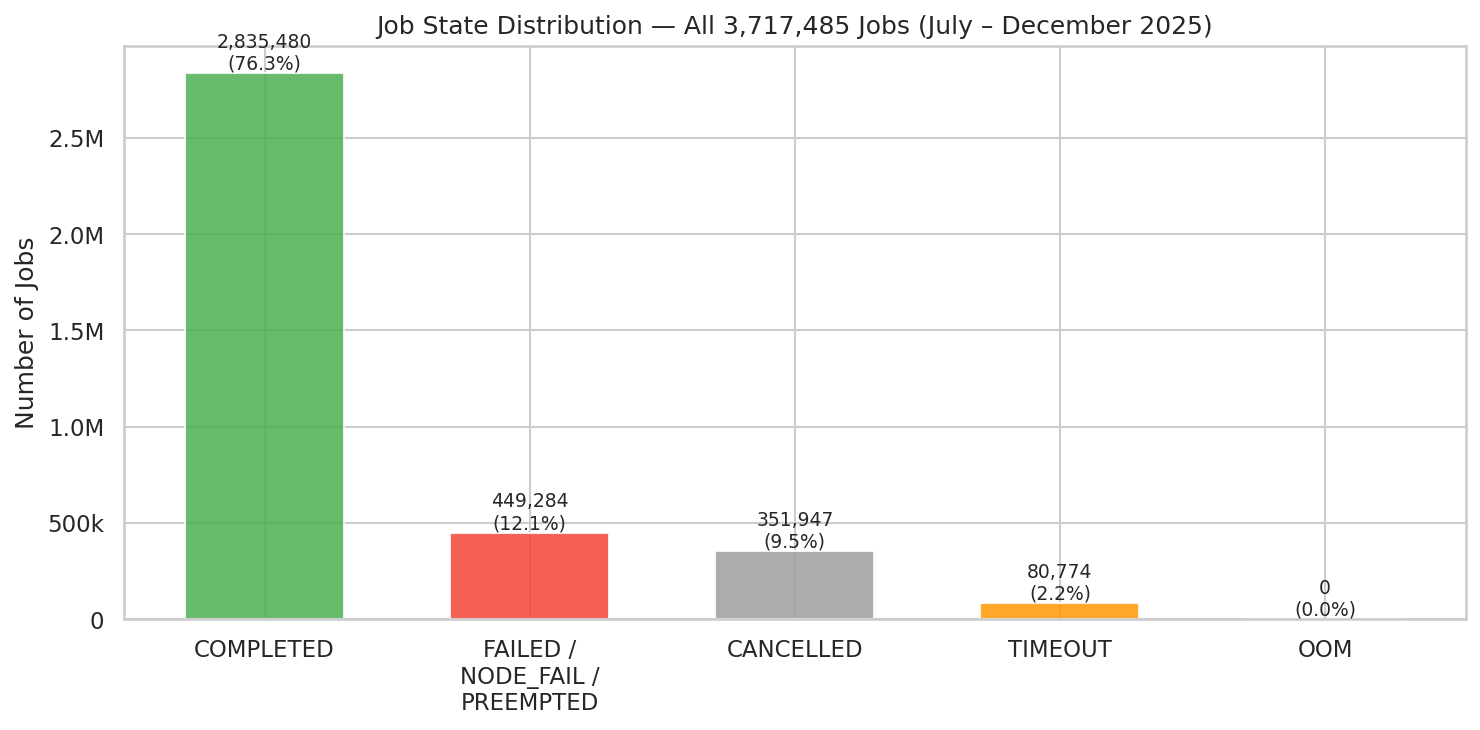


**Included in efficiency analysis:** COMPLETED + TIMEOUT + OOM
= **2,916,254** jobs.

**Excluded:** CANCELLED + FAILED + NODE_FAIL + PREEMPTED
= **801,231** jobs — these either did not run long enough or
terminated abnormally, so their resource usage is not representative.


In [4]:
# State breakdown from aggregate data
agg_completed = df_agg['job_count_success'].sum()
agg_timeout = df_agg['count_timeout'].sum()
agg_oom = df_agg['count_out_of_memory'].sum()
agg_failed_total = df_agg['job_count_failed'].sum()
agg_other_failed = agg_failed_total - agg_timeout - agg_oom
agg_cancelled = df_agg['cancelled'].sum()

state_labels = ['COMPLETED', 'FAILED /\nNODE_FAIL /\nPREEMPTED', 'CANCELLED', 'TIMEOUT', 'OOM']
state_counts = [agg_completed, agg_other_failed, agg_cancelled, agg_timeout, agg_oom]
state_colors = [C_OK, C_FAIL, C_CAN, '#FF9800', '#9C27B0']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(state_labels, state_counts, color=state_colors, edgecolor='white',
              width=0.6, alpha=0.85)

for bar, count in zip(bars, state_counts):
    pct = count / total_all * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Number of Jobs')
ax.yaxis.set_major_formatter(COUNT_FMT)
ax.set_title(f'Job State Distribution — All {total_all:,} Jobs ({DATE_RANGE})')
plt.tight_layout()
savefig('job_state_distribution.png')
plt.show()

display(Markdown(f'''
**Included in efficiency analysis:** COMPLETED + TIMEOUT + OOM
= **{total_eff:,}** jobs.

**Excluded:** CANCELLED + FAILED + NODE_FAIL + PREEMPTED
= **{total_excluded:,}** jobs — these either did not run long enough or
terminated abnormally, so their resource usage is not representative.
'''))

<>:30: SyntaxWarning: invalid escape sequence '\>'
<>:30: SyntaxWarning: invalid escape sequence '\>'
/tmp/ipykernel_93158/1877938864.py:30: SyntaxWarning: invalid escape sequence '\>'


  Saved cpu_efficiency_density.png


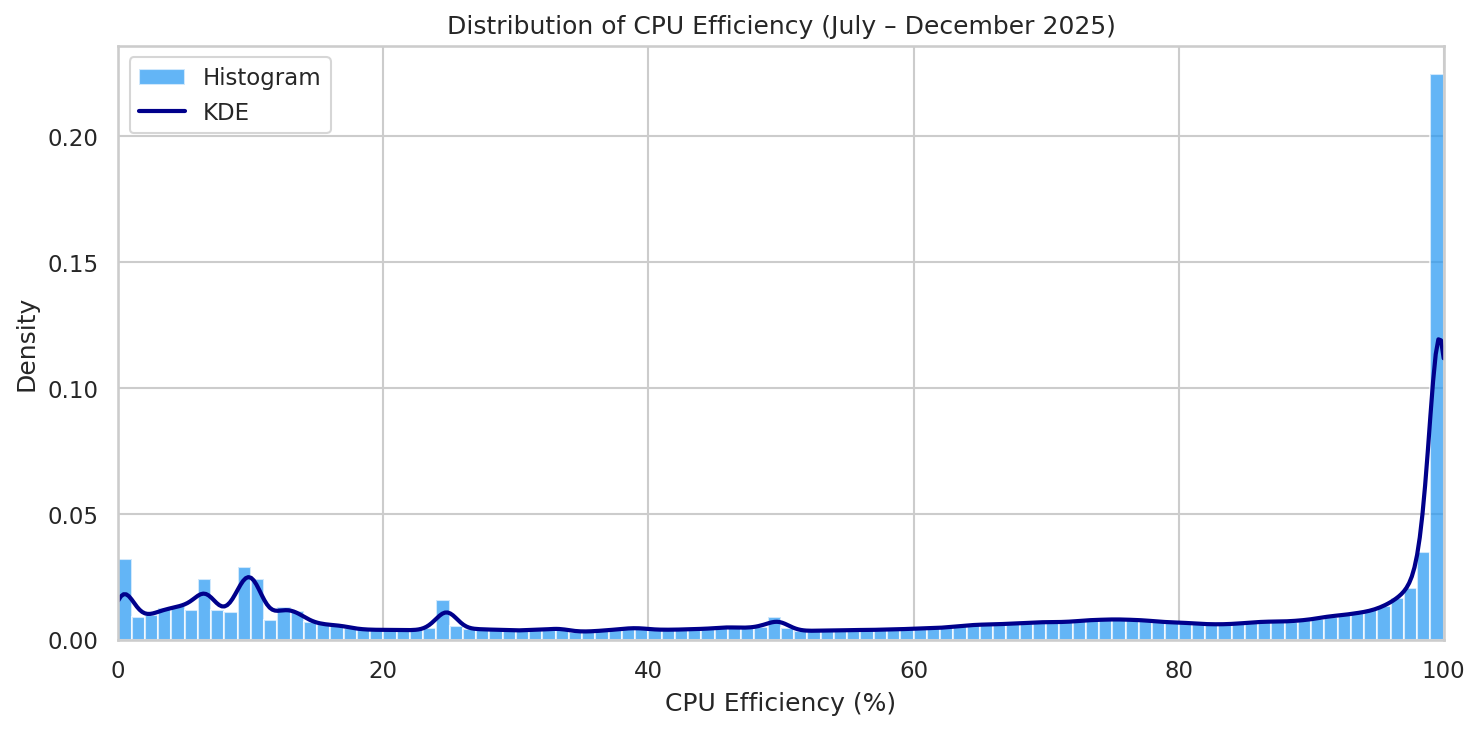


*Based on **2,807,463** jobs. From 2,916,254 efficiency jobs,
11,449 with null CPU efficiency and 97,342 with CPU efficiency
\> 100% were excluded.*


In [5]:
cpu_data = df['cpu_eff_req'].dropna()
cpu_plot = cpu_data[cpu_data <= 100]
cpu_null = total_eff - len(cpu_data)
cpu_over = len(cpu_data) - len(cpu_plot)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(cpu_plot, bins=100, color=C_CPU, alpha=0.7, edgecolor='white',
        density=True, label='Histogram')

# KDE overlay (subsample for speed)
sample = cpu_plot.sample(min(500_000, len(cpu_plot)), random_state=42)
kde = gaussian_kde(sample, bw_method=0.02)
x_grid = np.linspace(0, 100, 500)
ax.plot(x_grid, kde(x_grid), color='darkblue', lw=2, label='KDE')

ax.set_xlabel('CPU Efficiency (%)')
ax.set_ylabel('Density')
ax.set_title(f'Distribution of CPU Efficiency ({DATE_RANGE})')
ax.set_xlim(0, 100)
ax.legend()
plt.tight_layout()
savefig('cpu_efficiency_density.png')
plt.show()

display(Markdown(f'''
*Based on **{len(cpu_plot):,}** jobs. From {total_eff:,} efficiency jobs,
{cpu_null:,} with null CPU efficiency and {cpu_over:,} with CPU efficiency
\> 100% were excluded.*
'''))

  Saved cpu_efficiency_density_split.png


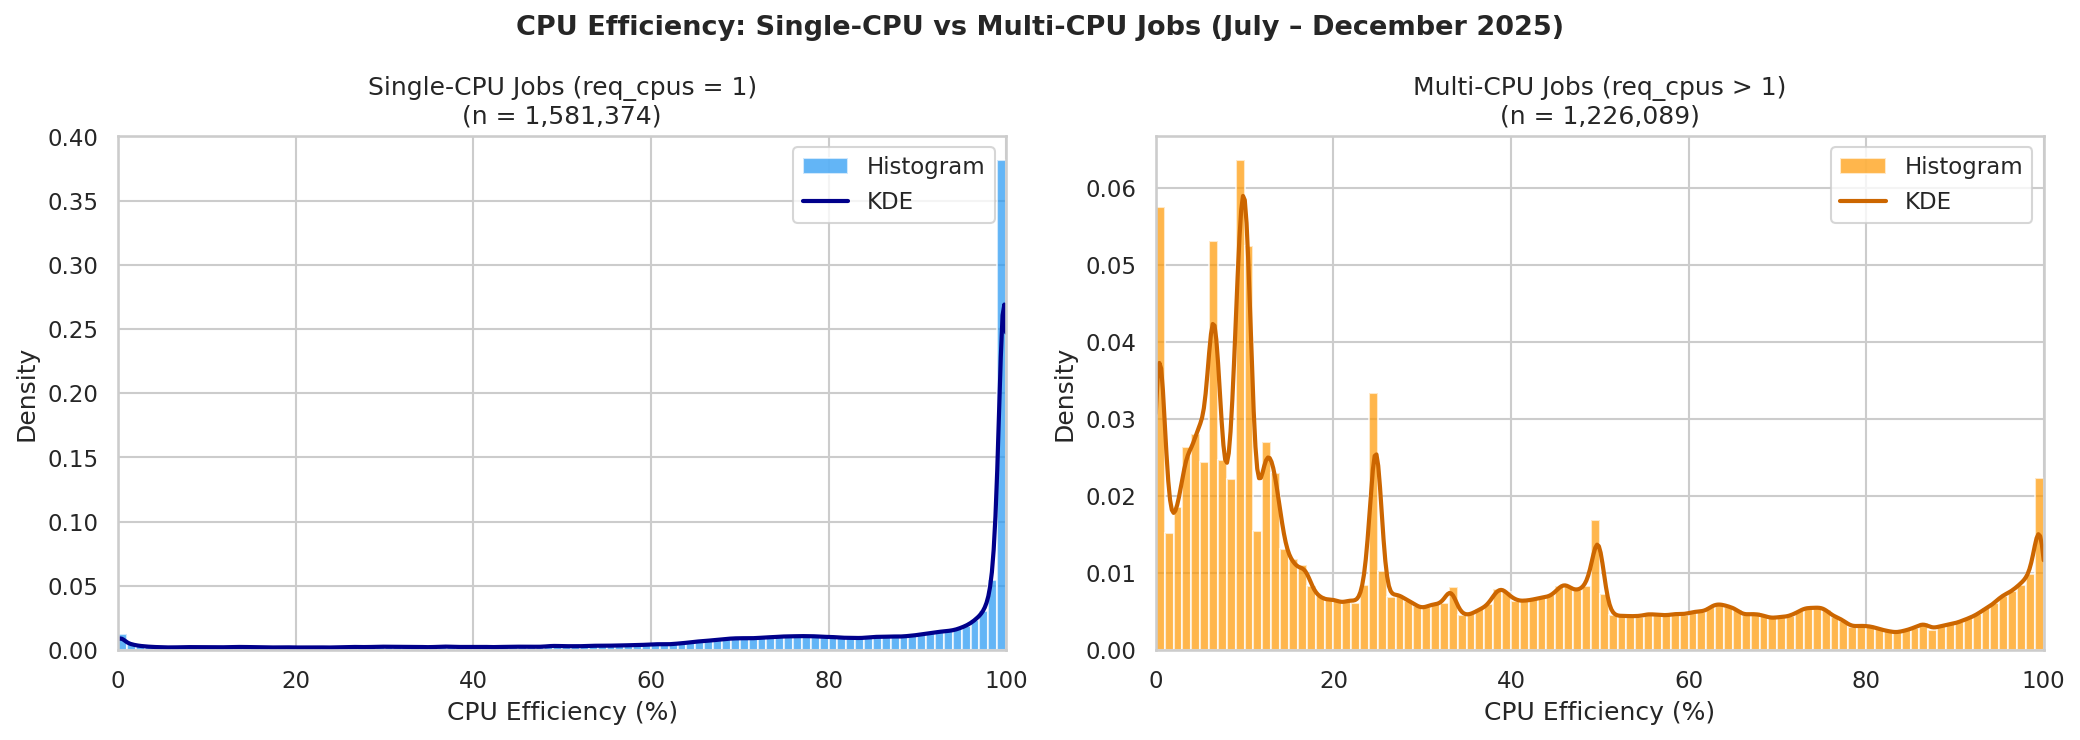


*Left: 1,581,374 single-CPU jobs (efficiency ≤ 100 %,
97,241 excluded).
Right: 1,226,089 multi-CPU jobs (efficiency ≤ 100 %,
101 excluded).*


In [6]:

# Split by single-CPU vs multi-CPU jobs
single_cpu = df[df['req_cpus'] == 1]
multi_cpu_all = df[df['req_cpus'] > 1]

single_cpu_eff = single_cpu['cpu_eff_req'].dropna()
single_cpu_plot = single_cpu_eff[single_cpu_eff <= 100]

multi_cpu_eff = multi_cpu_all['cpu_eff_req'].dropna()
multi_cpu_plot = multi_cpu_eff[multi_cpu_eff <= 100]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, color, dark, title, n_total, n_excluded in [
    (axes[0], single_cpu_plot, C_CPU, 'darkblue',
     'Single-CPU Jobs (req_cpus = 1)',
     len(single_cpu_eff), len(single_cpu_eff) - len(single_cpu_plot)),
    (axes[1], multi_cpu_plot, '#FF9800', '#CC6600',
     'Multi-CPU Jobs (req_cpus > 1)',
     len(multi_cpu_eff), len(multi_cpu_eff) - len(multi_cpu_plot)),
]:
    ax.hist(data, bins=100, color=color, alpha=0.7, edgecolor='white',
            density=True, label='Histogram')
    sample = data.sample(min(500_000, len(data)), random_state=42)
    kde = gaussian_kde(sample, bw_method=0.02)
    x_grid = np.linspace(0, 100, 500)
    ax.plot(x_grid, kde(x_grid), color=dark, lw=2, label='KDE')
    ax.set_xlabel('CPU Efficiency (%)')
    ax.set_ylabel('Density')
    ax.set_title(f'{title}\n(n = {len(data):,})')
    ax.set_xlim(0, 100)
    ax.legend()

plt.suptitle(f'CPU Efficiency: Single-CPU vs Multi-CPU Jobs ({DATE_RANGE})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('cpu_efficiency_density_split.png')
plt.show()

display(Markdown(f'''
*Left: {len(single_cpu_plot):,} single-CPU jobs (efficiency \u2264 100 %,
{len(single_cpu_eff) - len(single_cpu_plot):,} excluded).
Right: {len(multi_cpu_plot):,} multi-CPU jobs (efficiency \u2264 100 %,
{len(multi_cpu_eff) - len(multi_cpu_plot):,} excluded).*
'''))


<>:29: SyntaxWarning: invalid escape sequence '\>'
<>:29: SyntaxWarning: invalid escape sequence '\>'
/tmp/ipykernel_93158/1252737218.py:29: SyntaxWarning: invalid escape sequence '\>'


  Saved mem_efficiency_density.png


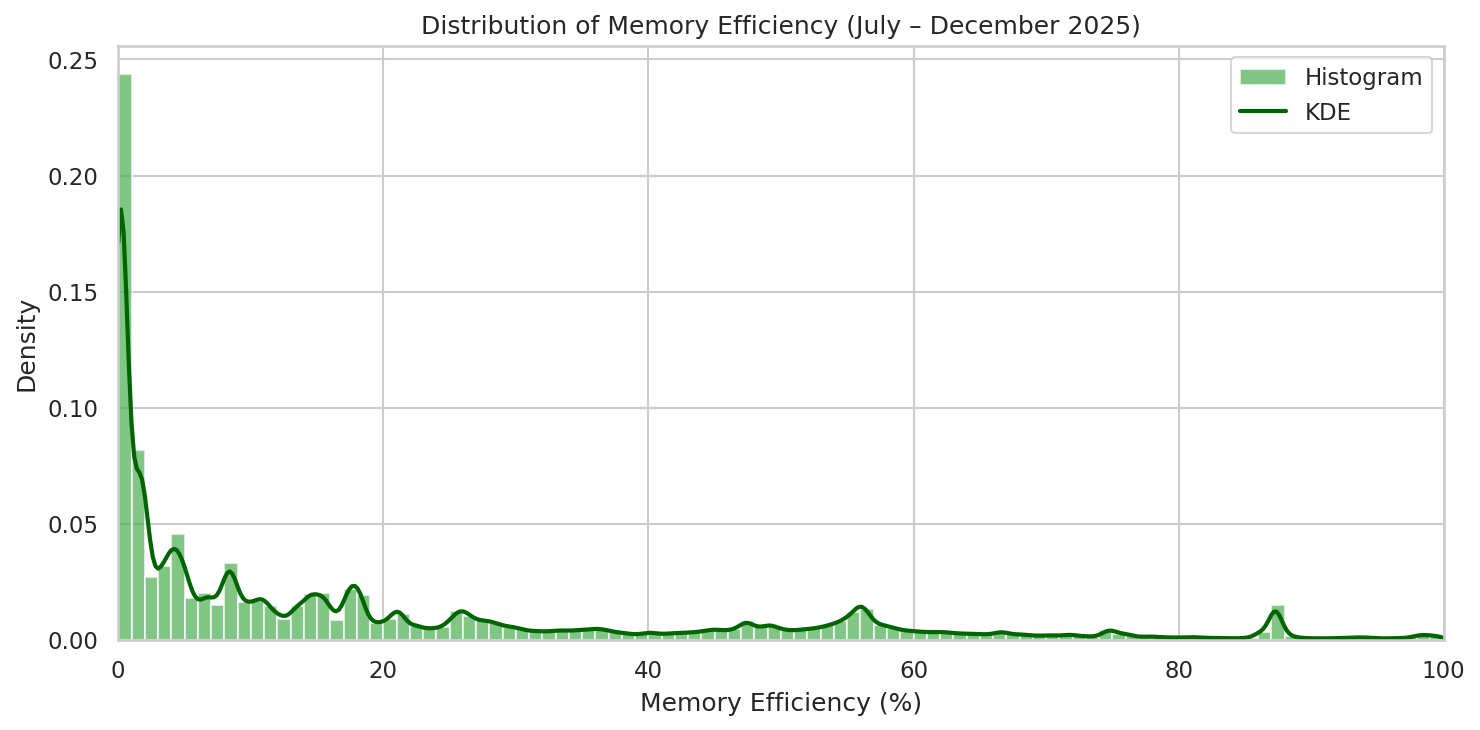


*Based on **2,641,826** jobs. From 2,916,254 efficiency jobs,
274 with null memory efficiency and 274,154 with memory
efficiency \> 100% were excluded.*


In [7]:
mem_data = df['mem_eff'].dropna()
mem_plot = mem_data[mem_data <= 100]
mem_null = total_eff - len(mem_data)
mem_over = len(mem_data) - len(mem_plot)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(mem_plot, bins=100, color=C_MEM, alpha=0.7, edgecolor='white',
        density=True, label='Histogram')

sample = mem_plot.sample(min(500_000, len(mem_plot)), random_state=42)
kde = gaussian_kde(sample, bw_method=0.02)
x_grid = np.linspace(0, 100, 500)
ax.plot(x_grid, kde(x_grid), color='darkgreen', lw=2, label='KDE')

ax.set_xlabel('Memory Efficiency (%)')
ax.set_ylabel('Density')
ax.set_title(f'Distribution of Memory Efficiency ({DATE_RANGE})')
ax.set_xlim(0, 100)
ax.legend()
plt.tight_layout()
savefig('mem_efficiency_density.png')
plt.show()

display(Markdown(f'''
*Based on **{len(mem_plot):,}** jobs. From {total_eff:,} efficiency jobs,
{mem_null:,} with null memory efficiency and {mem_over:,} with memory
efficiency \> 100% were excluded.*
'''))

In [ ]:
cpus = df['req_cpus'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: linear scale, zoomed to the most common range
top = int(cpus.quantile(0.99))
axes[0].hist(cpus[cpus <= top], bins=range(1, top + 2), color=C_CPU,
             alpha=0.7, edgecolor='white')
axes[0].set_xlabel('CPUs Requested')
axes[0].set_ylabel('Number of Jobs')
axes[0].yaxis.set_major_formatter(COUNT_FMT)
axes[0].set_title(f'Most common range (1\u2013{top} CPUs)')

# Right: log scale, showing the full range including outliers
axes[1].hist(cpus, bins=np.logspace(0, np.log10(cpus.max()), 50),
             color=C_CPU, alpha=0.7, edgecolor='white')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].xaxis.set_major_formatter(mticker.ScalarFormatter())
axes[1].yaxis.set_major_formatter(COUNT_FMT)
axes[1].set_xlabel('CPUs Requested')
axes[1].set_ylabel('Number of Jobs (log scale)')
axes[1].set_title('Full range including outliers (log scale)')

plt.suptitle(f'Distribution of CPUs Requested',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('cpus_requested_distribution.png')
plt.show()

# Summary statistics
display(Markdown(f'''
*Based on all {len(cpus):,} efficiency jobs. Bin size: 1 CPU (left plot). The left plot shows only jobs requesting up to
{top} CPUs (the 99th percentile), so the bulk of the distribution is visible.
The right plot uses logarithmic axes to show the full range.*

| Stat | Value |
|------|-------|
| Median | {cpus.median():.0f} |
| Mean | {cpus.mean():.1f} |
| 95th percentile | {cpus.quantile(0.95):.0f} |
| Max | {cpus.max():.0f} |
| % requesting 1 CPU | {(cpus == 1).mean()*100:.1f} % |
'''))

# Top 10 most frequent CPU request values
top10 = cpus.value_counts().head(10).sort_values(ascending=False)
rows = []
for val, count in top10.items():
    rows.append(f'| {int(val)} | {count:,} | {count / len(cpus) * 100:.1f} % |')
table = '\n'.join(rows)

display(Markdown(f'''
**Top 10 most frequently requested CPU counts:**

| CPUs | Jobs | % |
|------|------|---|
{table}
'''))

In [ ]:
mem_req_gib = df['reqmem_bytes'].dropna() / (1024**3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_mem = mem_req_gib.quantile(0.99)
n_bins_left = 50
bin_width = top_mem / n_bins_left
axes[0].hist(mem_req_gib[mem_req_gib <= top_mem], bins=n_bins_left,
             color=C_MEM, alpha=0.7, edgecolor='white')
axes[0].set_xlabel('Memory Requested (GiB)')
axes[0].set_ylabel('Number of Jobs')
axes[0].yaxis.set_major_formatter(COUNT_FMT)
axes[0].set_title(f'Most common range (up to {top_mem:.0f} GiB)')

axes[1].hist(mem_req_gib,
             bins=np.logspace(np.log10(max(0.01, mem_req_gib.min())),
                              np.log10(mem_req_gib.max()), 50),
             color=C_MEM, alpha=0.7, edgecolor='white')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].xaxis.set_major_formatter(mticker.ScalarFormatter())
axes[1].yaxis.set_major_formatter(COUNT_FMT)
axes[1].set_xlabel('Memory Requested (GiB)')
axes[1].set_ylabel('Number of Jobs (log scale)')
axes[1].set_title('Full range including outliers (log scale)')

plt.suptitle(f'Distribution of Memory Requested',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('memory_requested_distribution.png')
plt.show()

# Summary statistics
display(Markdown(f'''
*Based on all {len(mem_req_gib):,} efficiency jobs. Bin size: {bin_width:.1f} GiB (left plot). The left plot shows only jobs
requesting up to {top_mem:.0f} GiB (the 99th percentile). The right plot uses
logarithmic axes to show the full range.*

| Stat | Value |
|------|-------|
| Median | {mem_req_gib.median():.1f} GiB |
| Mean | {mem_req_gib.mean():.1f} GiB |
| 95th percentile | {mem_req_gib.quantile(0.95):.1f} GiB |
| Max | {mem_req_gib.max():.0f} GiB |
'''))

# Top 10 most frequent memory request values
mem_req_rounded = mem_req_gib.round(1)
top10m = mem_req_rounded.value_counts().head(10).sort_values(ascending=False)
rows = []
for val, count in top10m.items():
    rows.append(f'| {val:.1f} | {count:,} | {count / len(mem_req_gib) * 100:.1f} % |')
table = '\n'.join(rows)

display(Markdown(f'''
**Top 10 most frequently requested memory amounts:**

| GiB | Jobs | % |
|-----|------|---|
{table}
'''))

Jobs requesting > 1 CPU: 1,234,912 (42.3 % of all efficiency jobs)
  Saved ntasks_cpus_per_task_distribution.png


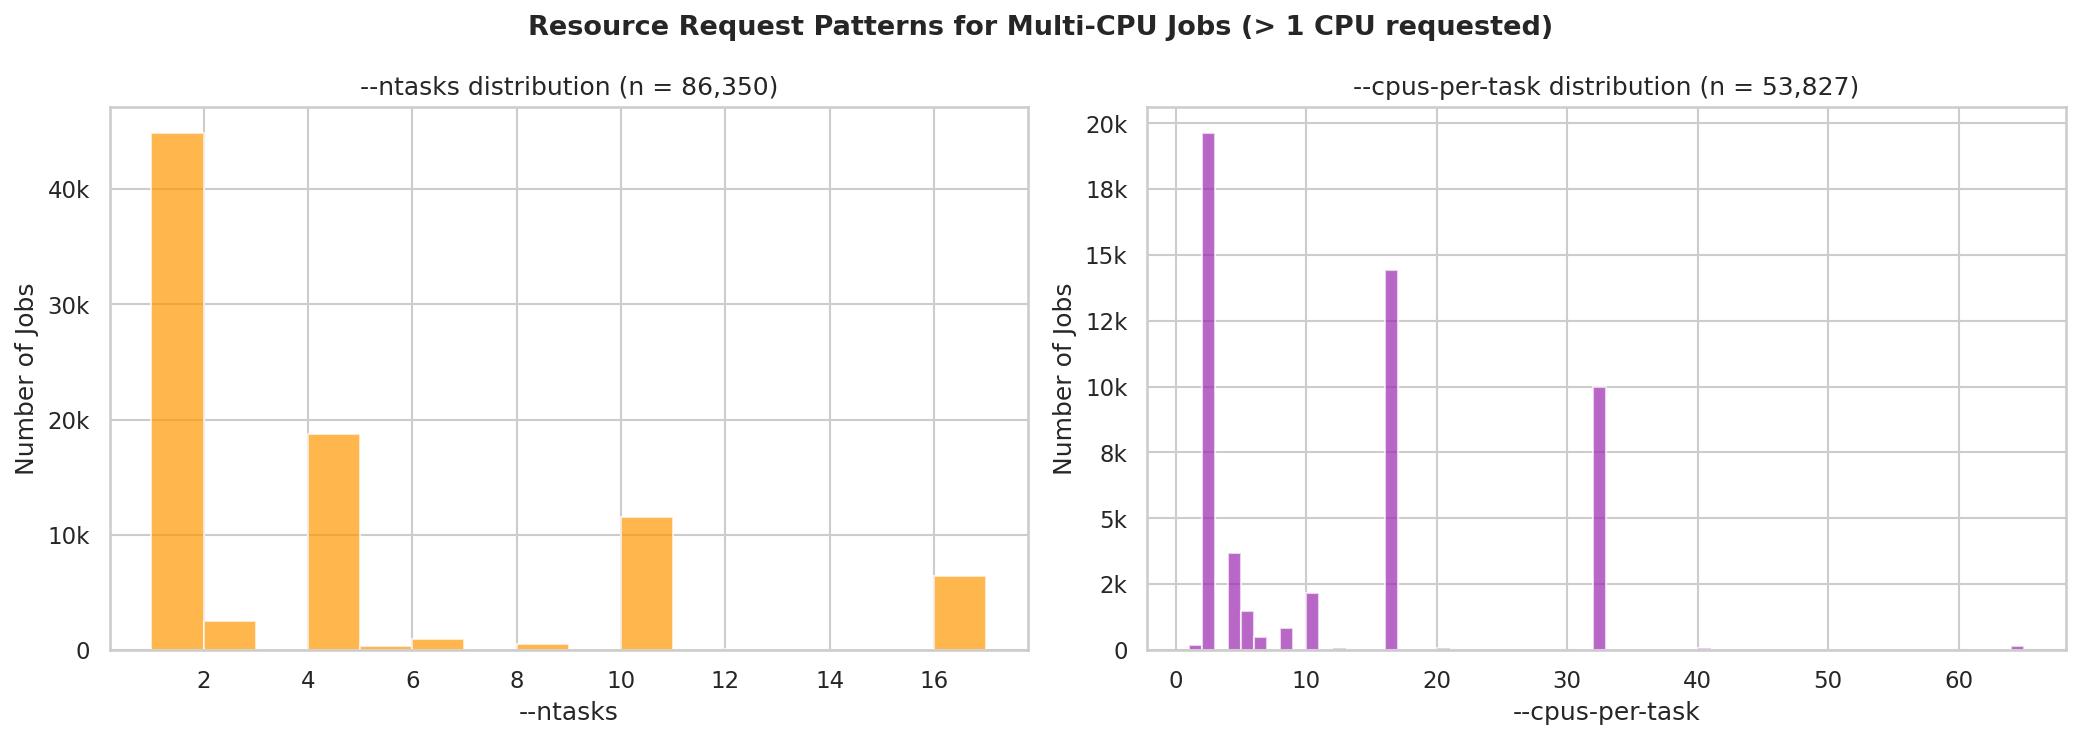


Of **1,234,912** jobs requesting more than 1 CPU:
- **41,186** (3.3 %) specified
  `--ntasks` only
- **8,663** (0.7 %) specified
  `--cpus-per-task` only
- **45,164** (3.7 %) specified **both** flags
- **1,139,899** (92.3 %) specified
  **neither** flag — these jobs obtained multiple CPUs through other means
  (e.g., `--ntasks-per-node`, `--nodes`, or Slurm defaults)


In [10]:
multi_cpu = df[df['req_cpus'] > 1].copy()
print(f'Jobs requesting > 1 CPU: {len(multi_cpu):,} '
      f'({len(multi_cpu)/len(df)*100:.1f} % of all efficiency jobs)')

has_ntasks = multi_cpu['submit_line_ntasks'].notna()
has_cpt    = multi_cpu['submit_line_cpus_per_task'].notna()

n_only_ntasks = (has_ntasks & ~has_cpt).sum()
n_only_cpt    = (~has_ntasks & has_cpt).sum()
n_both        = (has_ntasks & has_cpt).sum()
n_neither     = (~has_ntasks & ~has_cpt).sum()

ntasks = multi_cpu.loc[has_ntasks, 'submit_line_ntasks']
cpt    = multi_cpu.loc[has_cpt, 'submit_line_cpus_per_task']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(ntasks) > 0:
    top_nt = int(ntasks.quantile(0.99)) if len(ntasks) > 10 else int(ntasks.max())
    axes[0].hist(ntasks[ntasks <= top_nt],
                 bins=range(1, top_nt + 2),
                 color='#FF9800', alpha=0.7, edgecolor='white')
    axes[0].set_xlabel('--ntasks')
    axes[0].set_ylabel('Number of Jobs')
    axes[0].yaxis.set_major_formatter(COUNT_FMT)
    axes[0].set_title(f'--ntasks distribution (n = {len(ntasks):,})')
else:
    axes[0].text(0.5, 0.5, 'No --ntasks data', transform=axes[0].transAxes,
                 ha='center', fontsize=14)

if len(cpt) > 0:
    top_cpt = int(cpt.quantile(0.99)) if len(cpt) > 10 else int(cpt.max())
    axes[1].hist(cpt[cpt <= top_cpt],
                 bins=range(1, top_cpt + 2),
                 color='#9C27B0', alpha=0.7, edgecolor='white')
    axes[1].set_xlabel('--cpus-per-task')
    axes[1].set_ylabel('Number of Jobs')
    axes[1].yaxis.set_major_formatter(COUNT_FMT)
    axes[1].set_title(f'--cpus-per-task distribution (n = {len(cpt):,})')
else:
    axes[1].text(0.5, 0.5, 'No --cpus-per-task data',
                 transform=axes[1].transAxes, ha='center', fontsize=14)

plt.suptitle(f'Resource Request Patterns for Multi-CPU Jobs '
             f'(> 1 CPU requested)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('ntasks_cpus_per_task_distribution.png')
plt.show()

display(Markdown(f'''
Of **{len(multi_cpu):,}** jobs requesting more than 1 CPU:
- **{n_only_ntasks:,}** ({n_only_ntasks/len(multi_cpu)*100:.1f} %) specified
  `--ntasks` only
- **{n_only_cpt:,}** ({n_only_cpt/len(multi_cpu)*100:.1f} %) specified
  `--cpus-per-task` only
- **{n_both:,}** ({n_both/len(multi_cpu)*100:.1f} %) specified **both** flags
- **{n_neither:,}** ({n_neither/len(multi_cpu)*100:.1f} %) specified
  **neither** flag — these jobs obtained multiple CPUs through other means
  (e.g., `--ntasks-per-node`, `--nodes`, or Slurm defaults)
'''))


In [ ]:
both_flags = multi_cpu[multi_cpu['submit_line_ntasks'].notna()
                       & multi_cpu['submit_line_cpus_per_task'].notna()].copy()

if len(both_flags) > 10:
    fig, ax = plt.subplots(figsize=(8, 8))

    # Aggregate by unique (ntasks, cpus-per-task) pairs
    combo = both_flags.groupby(['submit_line_ntasks',
                                'submit_line_cpus_per_task']).size()
    combo = combo.reset_index(name='count')

    scatter = ax.scatter(
        combo['submit_line_ntasks'],
        combo['submit_line_cpus_per_task'],
        s=np.clip(combo['count'] / combo['count'].max() * 500, 10, 500),
        c=combo['count'], cmap='plasma',
        norm=mcolors.LogNorm(vmin=1, vmax=combo['count'].max()),
        alpha=0.8, edgecolors='grey', linewidths=0.5)
    fig.colorbar(scatter, ax=ax, label='Number of Jobs')

    ax.set_xlabel('--ntasks')
    ax.set_ylabel('--cpus-per-task')
    ax.set_title(f'Jobs specifying both flags (n = {len(both_flags):,})')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    plt.tight_layout()
    savefig('ntasks_vs_cpus_per_task.png')
    plt.show()

    display(Markdown(f'''
*Each dot represents a unique (`--ntasks`, `--cpus-per-task`) combination.
Dot size and colour both encode the number of jobs — larger and more yellow
means more jobs. The dominant pattern is `--ntasks=1` with varying
`--cpus-per-task`, indicating multi-threaded single-process workloads.*
'''))
else:
    print(f'Only {len(both_flags)} jobs specified both flags \u2014 '
          f'not enough for a meaningful scatter plot.')

  Saved severity_barplot.png


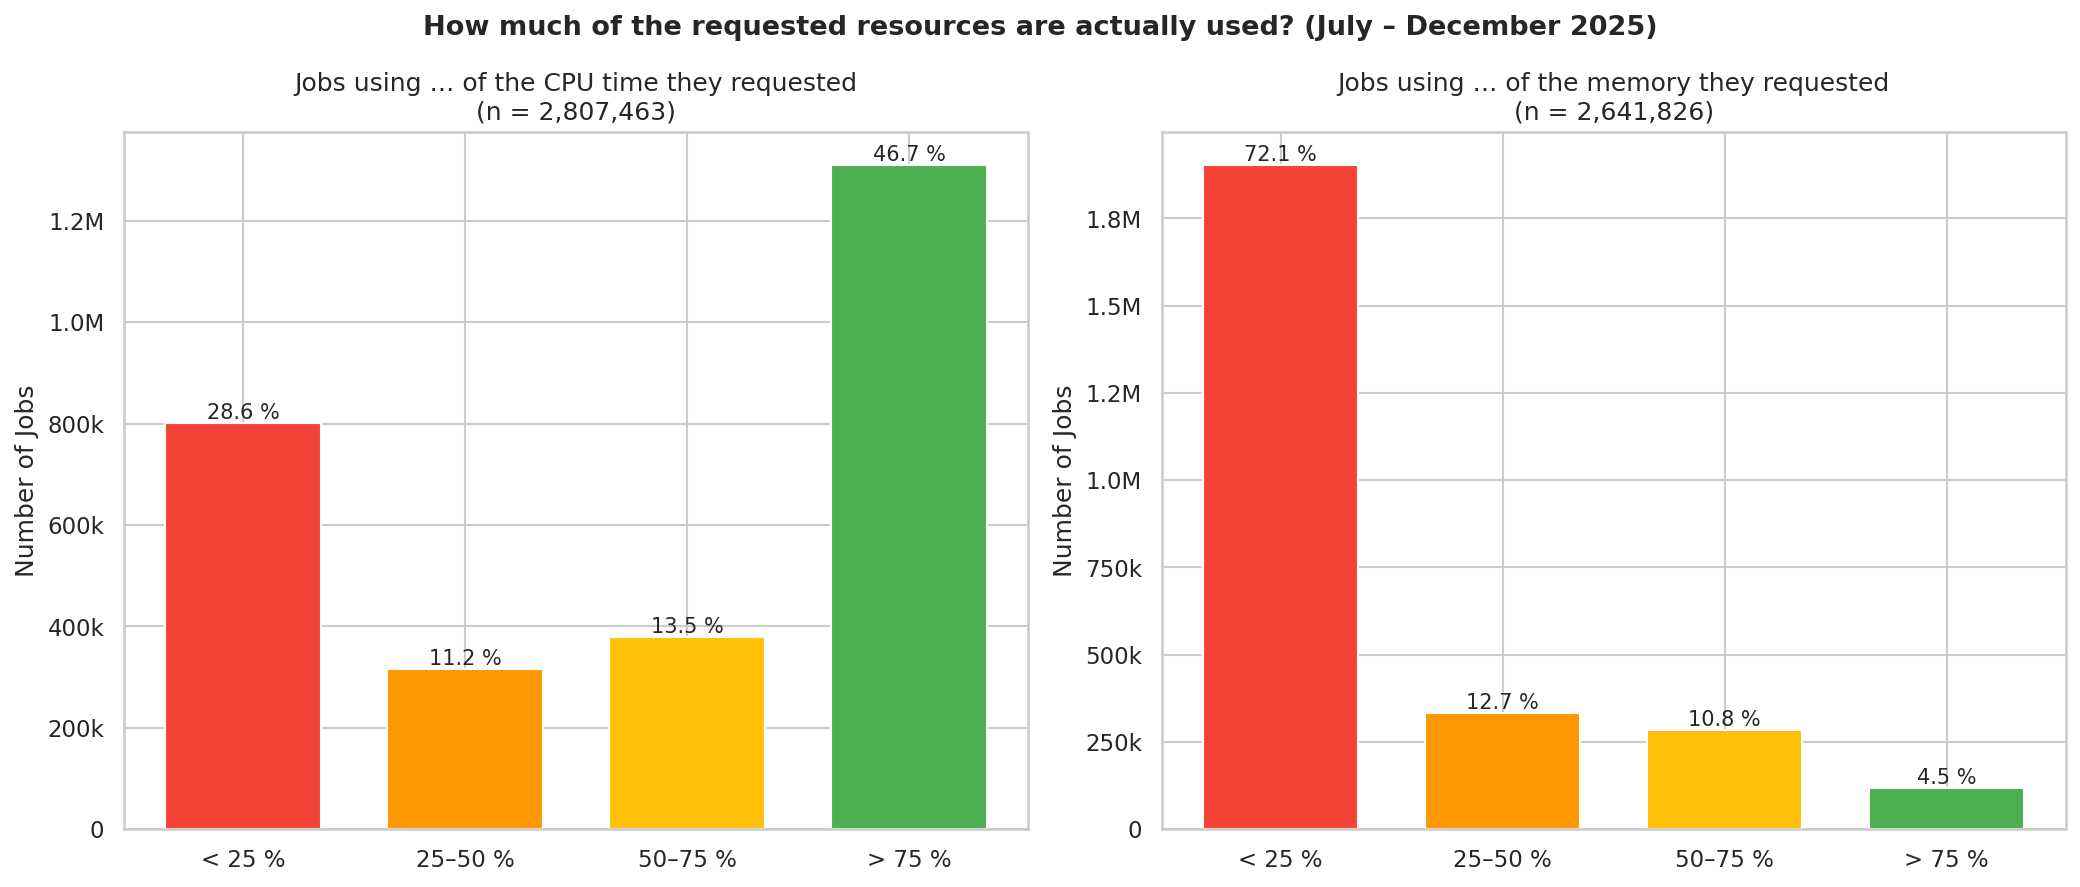


*Note on sample sizes:* The number of jobs in these plots differs from the
resource distribution plots above. The resource distributions show **all**
2,916,254 efficiency jobs. These severity plots only include jobs with a
**valid** efficiency value **≤ 100 %**. Of the 2,904,805 jobs
with a non-null CPU efficiency, 97,342 had efficiency > 100 % and
are excluded here. Jobs with null efficiency (e.g., zero elapsed time) are
also excluded.

CPU and memory efficiencies are filtered **independently** — a job can appear
in the CPU plot but not the memory plot, or vice versa.


In [12]:
bins   = [0, 25, 50, 75, 100.01]   # 100.01 to include exactly 100
labels = ['< 25 %', '25\u201350 %', '50\u201375 %', '> 75 %']
colors = ['#F44336', '#FF9800', '#FFC107', '#4CAF50']

cpu_filt = df['cpu_eff_req'].dropna()
cpu_filt = cpu_filt[cpu_filt <= 100]
mem_filt = df['mem_eff'].dropna()
mem_filt = mem_filt[mem_filt <= 100]

cpu_bins = pd.cut(cpu_filt, bins=bins, labels=labels, right=False)
mem_bins = pd.cut(mem_filt, bins=bins, labels=labels, right=False)

cpu_counts = cpu_bins.value_counts().reindex(labels, fill_value=0)
mem_counts = mem_bins.value_counts().reindex(labels, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, counts, resource, n in [
    (axes[0], cpu_counts, 'CPU time', len(cpu_filt)),
    (axes[1], mem_counts, 'memory', len(mem_filt)),
]:
    bars = ax.bar(labels, counts.values, color=colors, edgecolor='white',
                  width=0.7)
    ax.set_ylabel('Number of Jobs')
    ax.yaxis.set_major_formatter(COUNT_FMT)
    ax.set_title(f'Jobs using \u2026 of the {resource} they requested\n'
                 f'(n = {n:,})')
    for bar, v in zip(bars, counts.values):
        pct = v / n * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{pct:.1f} %', ha='center', va='bottom', fontsize=10)

plt.suptitle(f'How much of the requested resources are actually used? '
             f'({DATE_RANGE})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('severity_barplot.png')
plt.show()

n_cpu_all = df['req_cpus'].notna().sum()
n_cpu_valid_eff = df['cpu_eff_req'].notna().sum()
n_cpu_over100 = (df['cpu_eff_req'] > 100).sum()

display(Markdown(f'''
*Note on sample sizes:* The number of jobs in these plots differs from the
resource distribution plots above. The resource distributions show **all**
{n_cpu_all:,} efficiency jobs. These severity plots only include jobs with a
**valid** efficiency value **\u2264 100 %**. Of the {n_cpu_valid_eff:,} jobs
with a non-null CPU efficiency, {n_cpu_over100:,} had efficiency > 100 % and
are excluded here. Jobs with null efficiency (e.g., zero elapsed time) are
also excluded.

CPU and memory efficiencies are filtered **independently** — a job can appear
in the CPU plot but not the memory plot, or vice versa.
'''))


In [13]:
# --- Sentences for seff announcement email ---

# All jobs
total_jobs = total_all
avg_cpu_all = cpu_le100.mean()
below50_cpu_all = (cpu_le100 < 50).sum()
below50_cpu_all_pct = below50_cpu_all / len(cpu_le100) * 100

# Memory (all jobs)
avg_mem_all = mem_le100.mean()
below50_mem_all = (mem_le100 < 50).sum()
below50_mem_all_pct = below50_mem_all / len(mem_le100) * 100

# Multi-CPU jobs only
multi_cpu_eff_email = df.loc[df['req_cpus'] > 1, 'cpu_eff_req'].dropna()
multi_cpu_eff_email = multi_cpu_eff_email[multi_cpu_eff_email <= 100]
avg_cpu_multi = multi_cpu_eff_email.mean()
below50_cpu_multi = (multi_cpu_eff_email < 50).sum()
below50_cpu_multi_pct = below50_cpu_multi / len(multi_cpu_eff_email) * 100

multi_mem_eff_email = df.loc[df['req_cpus'] > 1, 'mem_eff'].dropna()
multi_mem_eff_email = multi_mem_eff_email[multi_mem_eff_email <= 100]
avg_mem_multi = multi_mem_eff_email.mean()
below50_mem_multi = (multi_mem_eff_email < 50).sum()
below50_mem_multi_pct = below50_mem_multi / len(multi_mem_eff_email) * 100

# Exclusion counts
cpu_null = total_eff - len(cpu_valid)
cpu_over100 = len(cpu_valid) - len(cpu_le100)
mem_null = total_eff - len(mem_valid)
mem_over100 = len(mem_valid) - len(mem_le100)

display(Markdown(f'''
### Email text: suggested sentences

**Version 1 — all jobs:**

> Over the last six months, **{total_jobs:,}** jobs were run on CREATE HPC.
> Of **{len(cpu_le100):,}** jobs we could analyse, the average CPU efficiency
> was **{avg_cpu_all:.0f}%** — **{below50_cpu_all:,}** ({below50_cpu_all_pct:.0f}%)
> used less than 50% of the CPU time they requested!
> The average memory efficiency was **{avg_mem_all:.0f}%**
> (across {len(mem_le100):,} jobs) — **{below50_mem_all:,}**
> ({below50_mem_all_pct:.0f}%) used less than 50% of the memory they requested.

**Version 2 — multi-CPU jobs only:**

> Of the **{len(multi_cpu_eff_email):,}** multi-CPU jobs we could analyse,
> the average CPU efficiency was **{avg_cpu_multi:.0f}%** —
> **{below50_cpu_multi:,}** ({below50_cpu_multi_pct:.0f}%) used less than 50%
> of the CPU time they requested!
> The average memory efficiency was **{avg_mem_multi:.0f}%**
> (across {len(multi_mem_eff_email):,} jobs) — **{below50_mem_multi:,}**
> ({below50_mem_multi_pct:.0f}%) used less than 50% of the memory they
> requested.

---

*How we arrived at these numbers:*

*Of {total_jobs:,} total jobs, {total_eff:,} were in states COMPLETED,
TIMEOUT, or OUT_OF_MEMORY — these ran long enough to produce meaningful
resource usage data. The remaining {total_excluded:,} (CANCELLED, FAILED,
NODE_FAIL, PREEMPTED) were excluded.*

*From those {total_eff:,} jobs, we further excluded:*
- *CPU: {cpu_null:,} with null efficiency + {cpu_over100:,} with efficiency
  > 100% = **{len(cpu_le100):,}** analysed*
- *Memory: {mem_null:,} with null efficiency + {mem_over100:,} with efficiency
  > 100% = **{len(mem_le100):,}** analysed*
'''))


### Email text: suggested sentences

**Version 1 — all jobs:**

> Over the last six months, **3,717,485** jobs were run on CREATE HPC.
> Of **2,807,463** jobs we could analyse, the average CPU efficiency
> was **60%** — **1,117,361** (40%)
> used less than 50% of the CPU time they requested!
> The average memory efficiency was **19%**
> (across 2,641,826 jobs) — **2,238,026**
> (85%) used less than 50% of the memory they requested.

**Version 2 — multi-CPU jobs only:**

> Of the **1,226,089** multi-CPU jobs we could analyse,
> the average CPU efficiency was **32%** —
> **920,327** (75%) used less than 50%
> of the CPU time they requested!
> The average memory efficiency was **13%**
> (across 1,101,609 jobs) — **1,028,429**
> (93%) used less than 50% of the memory they
> requested.

---

*How we arrived at these numbers:*

*Of 3,717,485 total jobs, 2,916,254 were in states COMPLETED,
TIMEOUT, or OUT_OF_MEMORY — these ran long enough to produce meaningful
resource usage data. The remaining 801,231 (CANCELLED, FAILED,
NODE_FAIL, PREEMPTED) were excluded.*

*From those 2,916,254 jobs, we further excluded:*
- *CPU: 11,449 with null efficiency + 97,342 with efficiency
  > 100% = **2,807,463** analysed*
- *Memory: 274 with null efficiency + 274,154 with efficiency
  > 100% = **2,641,826** analysed*


In [ ]:
scatter_df = df[['elapsed_sec', 'req_cpus', 'total_cpu_sec',
                  'cpu_eff_req']].dropna()
scatter_df = scatter_df[scatter_df['cpu_eff_req'] <= 100]
scatter_df['cpu_req_hrs'] = (scatter_df['elapsed_sec']
                             * scatter_df['req_cpus'] / 3600)
scatter_df['cpu_used_hrs'] = scatter_df['total_cpu_sec'] / 3600
scatter_df['eff'] = scatter_df['cpu_eff_req']

# Filter out zeros for log scale
scatter_df = scatter_df[(scatter_df['cpu_req_hrs'] > 0)
                        & (scatter_df['cpu_used_hrs'] > 0)]

# Subsample for scatter plot
sample = scatter_df.sample(min(80_000, len(scatter_df)), random_state=42)

fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(sample['cpu_req_hrs'], sample['cpu_used_hrs'],
                c=sample['eff'], cmap='RdYlBu', vmin=0, vmax=100,
                s=3, alpha=0.4, edgecolors='none', rasterized=True)
fig.colorbar(sc, ax=ax, label='CPU Efficiency (%)')

# Diagonal (100 % efficiency)
lims = [scatter_df['cpu_req_hrs'].min(), scatter_df['cpu_req_hrs'].max()]
ax.plot(lims, lims, 'k--', lw=1.5, alpha=0.5, label='100 % efficiency')

ax.set_xlabel('CPU Time Requested (hours)')
ax.set_ylabel('CPU Time Used (hours)')
ax.set_title(f'CPU Time: Requested vs Used (n = {len(scatter_df):,})')
ax.set_xscale('log')
ax.set_yscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
savefig('cpu_requested_vs_used.png')
plt.show()

In [ ]:
mem_sc = df[['reqmem_bytes', 'maxrss_bytes', 'mem_eff']].dropna()
mem_sc = mem_sc[mem_sc['mem_eff'] <= 100]
mem_sc['req_gib']  = mem_sc['reqmem_bytes'] / (1024**3)
mem_sc['used_gib'] = mem_sc['maxrss_bytes'] / (1024**3)
mem_sc['eff'] = mem_sc['mem_eff']

# Filter out zeros for log scale
mem_sc = mem_sc[(mem_sc['req_gib'] > 0) & (mem_sc['used_gib'] > 0)]

sample = mem_sc.sample(min(80_000, len(mem_sc)), random_state=42)

fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(sample['req_gib'], sample['used_gib'],
                c=sample['eff'], cmap='RdYlBu', vmin=0, vmax=100,
                s=3, alpha=0.4, edgecolors='none', rasterized=True)
fig.colorbar(sc, ax=ax, label='Memory Efficiency (%)')

lims = [mem_sc['req_gib'].min(), mem_sc['req_gib'].max()]
ax.plot(lims, lims, 'k--', lw=1.5, alpha=0.5, label='100 % efficiency')

ax.set_xlabel('Memory Requested (GiB)')
ax.set_ylabel('Memory Used (GiB)')
ax.set_title(f'Memory: Requested vs Used (n = {len(mem_sc):,})')
ax.set_xscale('log')
ax.set_yscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
savefig('mem_requested_vs_used.png')
plt.show()

  Saved cpu_vs_mem_efficiency.png


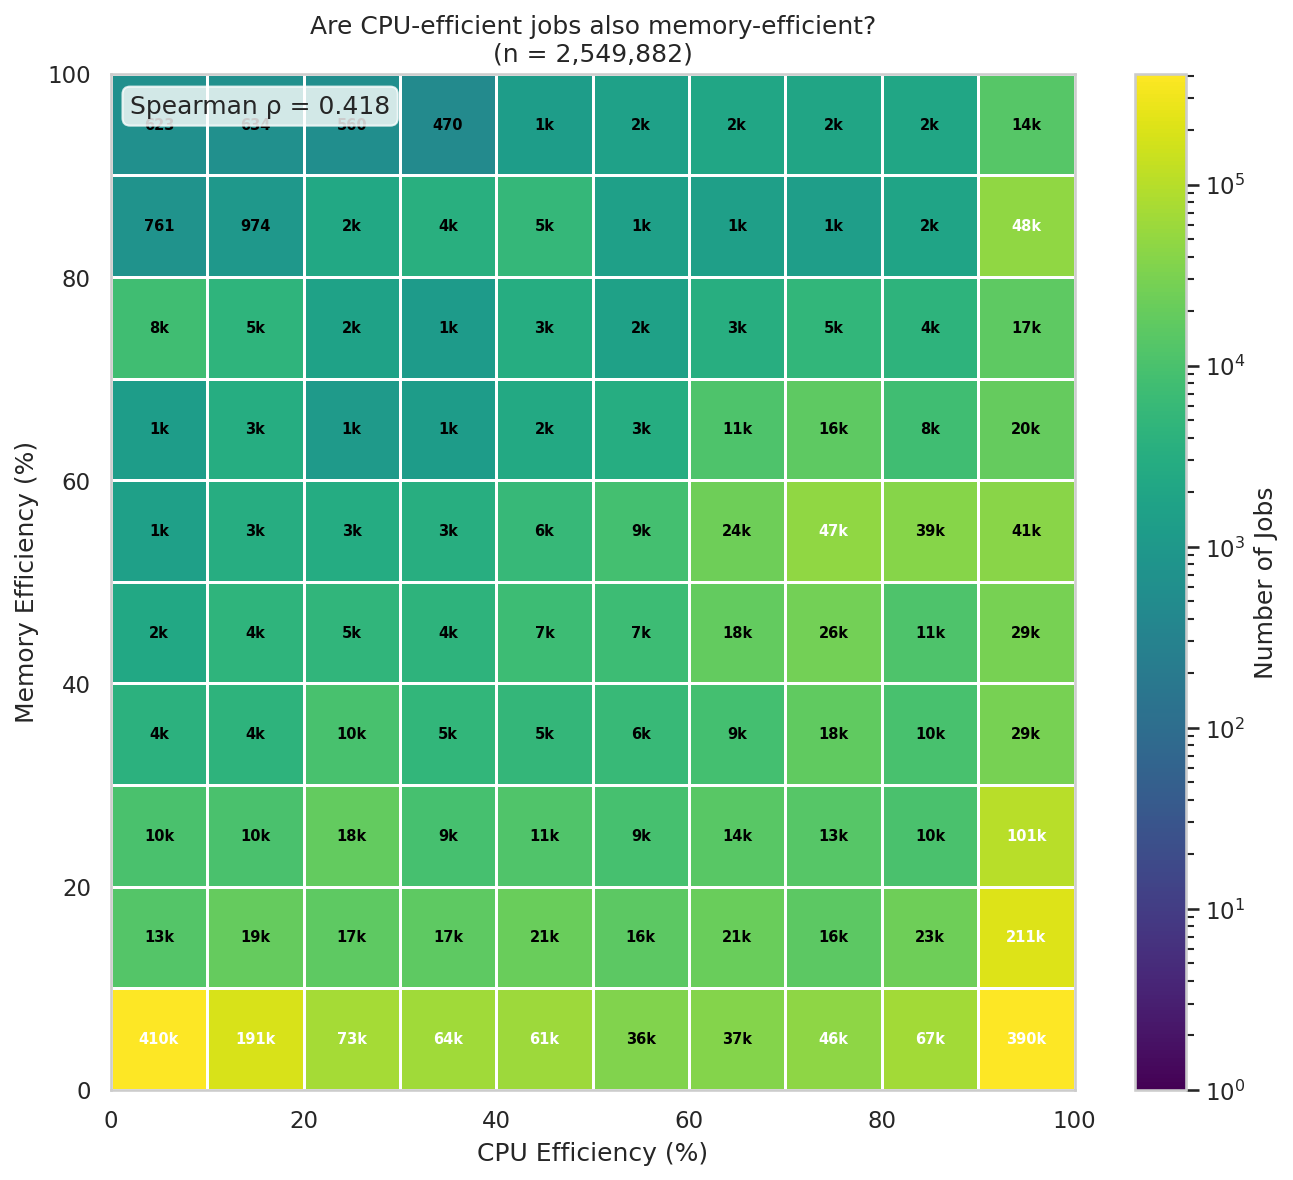

In [16]:
both = df[['cpu_eff_req', 'mem_eff']].dropna()
both = both[(both['cpu_eff_req'] <= 100) & (both['mem_eff'] <= 100)]

# 2D histogram with 10% bins
bins_10 = np.arange(0, 110, 10)
H, xedges, yedges = np.histogram2d(
    both['cpu_eff_req'], both['mem_eff'], bins=[bins_10, bins_10])

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.pcolormesh(xedges, yedges, H.T,
                   cmap='viridis',
                   norm=mcolors.LogNorm(vmin=1, vmax=H.max()),
                   edgecolors='white', linewidth=0.5)
fig.colorbar(im, ax=ax, label='Number of Jobs')

# Annotate each cell with count
for i in range(len(bins_10) - 1):
    for j in range(len(bins_10) - 1):
        count = int(H[i, j])
        if count > 0:
            x_center = (xedges[i] + xedges[i + 1]) / 2
            y_center = (yedges[j] + yedges[j + 1]) / 2
            # Use white text on dark cells, black on light cells
            text_color = 'white' if count > H.max() * 0.1 else 'black'
            if count >= 1_000_000:
                label = f'{count/1_000_000:.1f}M'
            elif count >= 1000:
                label = f'{count/1000:.0f}k'
            else:
                label = str(count)
            ax.text(x_center, y_center, label,
                    ha='center', va='center', fontsize=7,
                    color=text_color, fontweight='bold')

ax.set_xlabel('CPU Efficiency (%)')
ax.set_ylabel('Memory Efficiency (%)')
ax.set_title(f'Are CPU-efficient jobs also memory-efficient?\n'
             f'(n = {len(both):,})')

# Spearman correlation
rho, pval = sp_stats.spearmanr(both['cpu_eff_req'], both['mem_eff'])
ax.text(0.02, 0.98, f'Spearman \u03c1 = {rho:.3f}',
        transform=ax.transAxes, fontsize=12, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
savefig('cpu_vs_mem_efficiency.png')
plt.show()


---
# 2. Faculty Efficiency Stats

In [ ]:
def faculty_ci_stats(col):
    """Compute per-faculty mean and 95% CI from job-level data (eff <= 100%)."""
    rows = []
    for fac in df['faculty'].unique():
        vals = df.loc[df['faculty'] == fac, col].dropna()
        vals = vals[vals <= 100]
        if len(vals) < 5:
            continue
        mean = vals.mean()
        se   = vals.std() / np.sqrt(len(vals))
        ci   = 1.96 * se
        rows.append({
            'faculty': fac,
            'faculty_short': SHORT.get(fac, fac),
            'mean': mean,
            'ci': ci,
            'n': len(vals),
        })
    return pd.DataFrame(rows).sort_values('mean', ascending=True)

cpu_fstats = faculty_ci_stats('cpu_eff_req')
mem_fstats = faculty_ci_stats('mem_eff')

fig, axes = plt.subplots(1, 2, figsize=(18, max(8, len(cpu_fstats) * 0.6)))

for ax, fstats, color, title in [
    (axes[0], cpu_fstats, C_CPU, 'Average CPU Efficiency by Faculty'),
    (axes[1], mem_fstats, C_MEM, 'Average Memory Efficiency by Faculty'),
]:
    y = range(len(fstats))
    ax.barh(y, fstats['mean'], xerr=fstats['ci'],
            color=color, alpha=0.7, edgecolor='white',
            capsize=3, error_kw={'lw': 1})
    ax.set_yticks(list(y))
    ax.set_yticklabels(fstats['faculty_short'], fontsize=9)
    ax.set_xlabel('Efficiency (%)')
    ax.set_title(title)
    ax.set_xlim(0, 105)
    ax.axvline(50, color='orange', ls='--', alpha=0.4)
    ax.axvline(100, color='green', ls='--', alpha=0.4)

    # Annotate job counts at tip of bar
    for i, (_, row) in enumerate(fstats.iterrows()):
        ax.text(row['mean'] + row['ci'] + 1, i,
                f'{row["n"]:,}', va='center', fontsize=10)

plt.suptitle(f'Faculty Efficiency Rankings with 95 % CI ({DATE_RANGE})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('faculty_efficiency_barplots.png')
plt.show()

display(Markdown('''
*Numbers at the tip of each bar indicate the number of jobs included
(with valid efficiency ≤ 100 %). Error bars show 95 % confidence intervals
around the mean.*
'''))

  Saved faculty_efficiency_violins.png


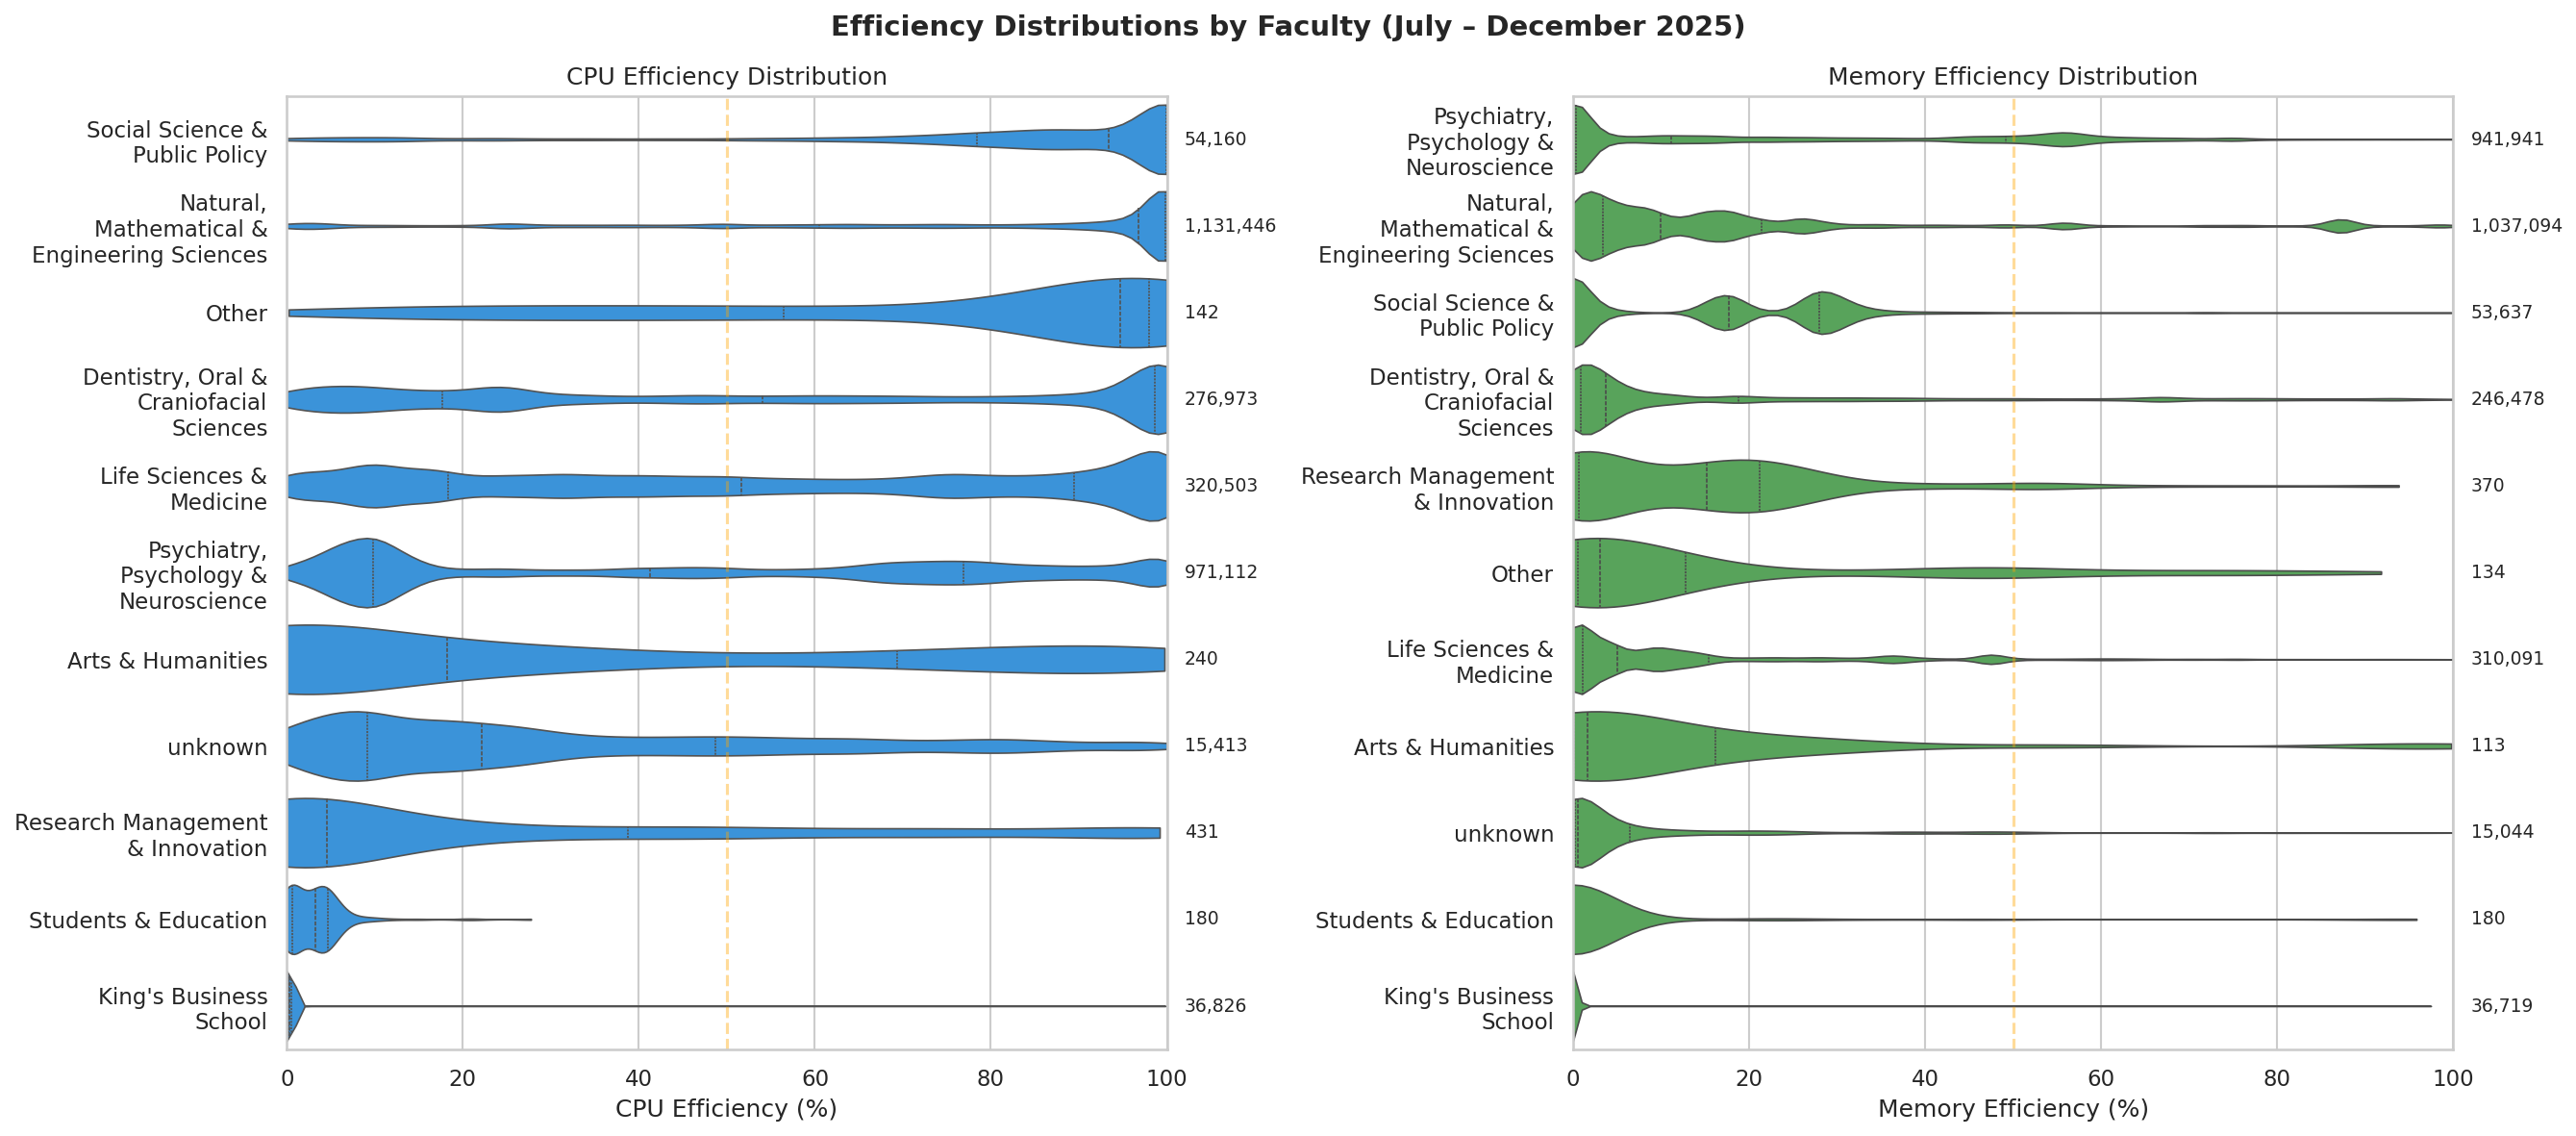


*Numbers next to each violin indicate the number of jobs included
(with valid efficiency ≤ 100 %). Faculties with fewer than 50 jobs are
excluded. Internal lines show quartiles (25th, 50th, 75th percentile).*


In [18]:
# Only faculties with >= 50 jobs for meaningful violins
fac_counts = df['faculty'].value_counts()
big_facs = fac_counts[fac_counts >= 50].index.tolist()

# Order by mean CPU efficiency (desc) for CPU, by mean mem eff for mem
fac_cpu_means = (df[df['faculty'].isin(big_facs) & (df['cpu_eff_req'] <= 100)
                    & df['cpu_eff_req'].notna()]
                 .groupby('faculty')['cpu_eff_req'].mean()
                 .sort_values(ascending=False))
fac_order_cpu = [SHORT.get(f, f) for f in fac_cpu_means.index]

fac_mem_means = (df[df['faculty'].isin(big_facs) & (df['mem_eff'] <= 100)
                    & df['mem_eff'].notna()]
                 .groupby('faculty')['mem_eff'].mean()
                 .sort_values(ascending=False))
fac_order_mem = [SHORT.get(f, f) for f in fac_mem_means.index]

fig, axes = plt.subplots(1, 2, figsize=(18, max(8, len(big_facs) * 0.65)))

# CPU violin
cpu_vdata = df[df['faculty'].isin(big_facs)
               & df['cpu_eff_req'].notna()
               & (df['cpu_eff_req'] <= 100)].copy()
sns.violinplot(data=cpu_vdata, y='faculty_short', x='cpu_eff_req',
               ax=axes[0], cut=0, order=fac_order_cpu,
               density_norm='width', inner='quartile', color=C_CPU,
               linewidth=0.8)
axes[0].set_xlabel('CPU Efficiency (%)')
axes[0].set_ylabel('')
axes[0].set_title('CPU Efficiency Distribution')
axes[0].axvline(50, color='orange', ls='--', alpha=0.4)
axes[0].set_xlim(0, 100)

# Annotate with job counts
for i, fac_short in enumerate(fac_order_cpu):
    fac_full = [k for k, v in SHORT.items() if v == fac_short]
    if fac_full:
        n = len(cpu_vdata[cpu_vdata['faculty'] == fac_full[0]])
        axes[0].text(102, i, f'{n:,}', va='center', fontsize=9)

# Memory violin
mem_vdata = df[df['faculty'].isin(big_facs)
               & df['mem_eff'].notna()
               & (df['mem_eff'] <= 100)].copy()
sns.violinplot(data=mem_vdata, y='faculty_short', x='mem_eff',
               ax=axes[1], cut=0, order=fac_order_mem,
               density_norm='width', inner='quartile', color=C_MEM,
               linewidth=0.8)
axes[1].set_xlabel('Memory Efficiency (%)')
axes[1].set_ylabel('')
axes[1].set_title('Memory Efficiency Distribution')
axes[1].axvline(50, color='orange', ls='--', alpha=0.4)
axes[1].set_xlim(0, 100)

for i, fac_short in enumerate(fac_order_mem):
    fac_full = [k for k, v in SHORT.items() if v == fac_short]
    if fac_full:
        n = len(mem_vdata[mem_vdata['faculty'] == fac_full[0]])
        axes[1].text(102, i, f'{n:,}', va='center', fontsize=9)

plt.suptitle(f'Efficiency Distributions by Faculty ({DATE_RANGE})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('faculty_efficiency_violins.png')
plt.show()

display(Markdown('''
*Numbers next to each violin indicate the number of jobs included
(with valid efficiency \u2264 100 %). Faculties with fewer than 50 jobs are
excluded. Internal lines show quartiles (25th, 50th, 75th percentile).*
'''))


  Saved faculty_job_outcomes.png


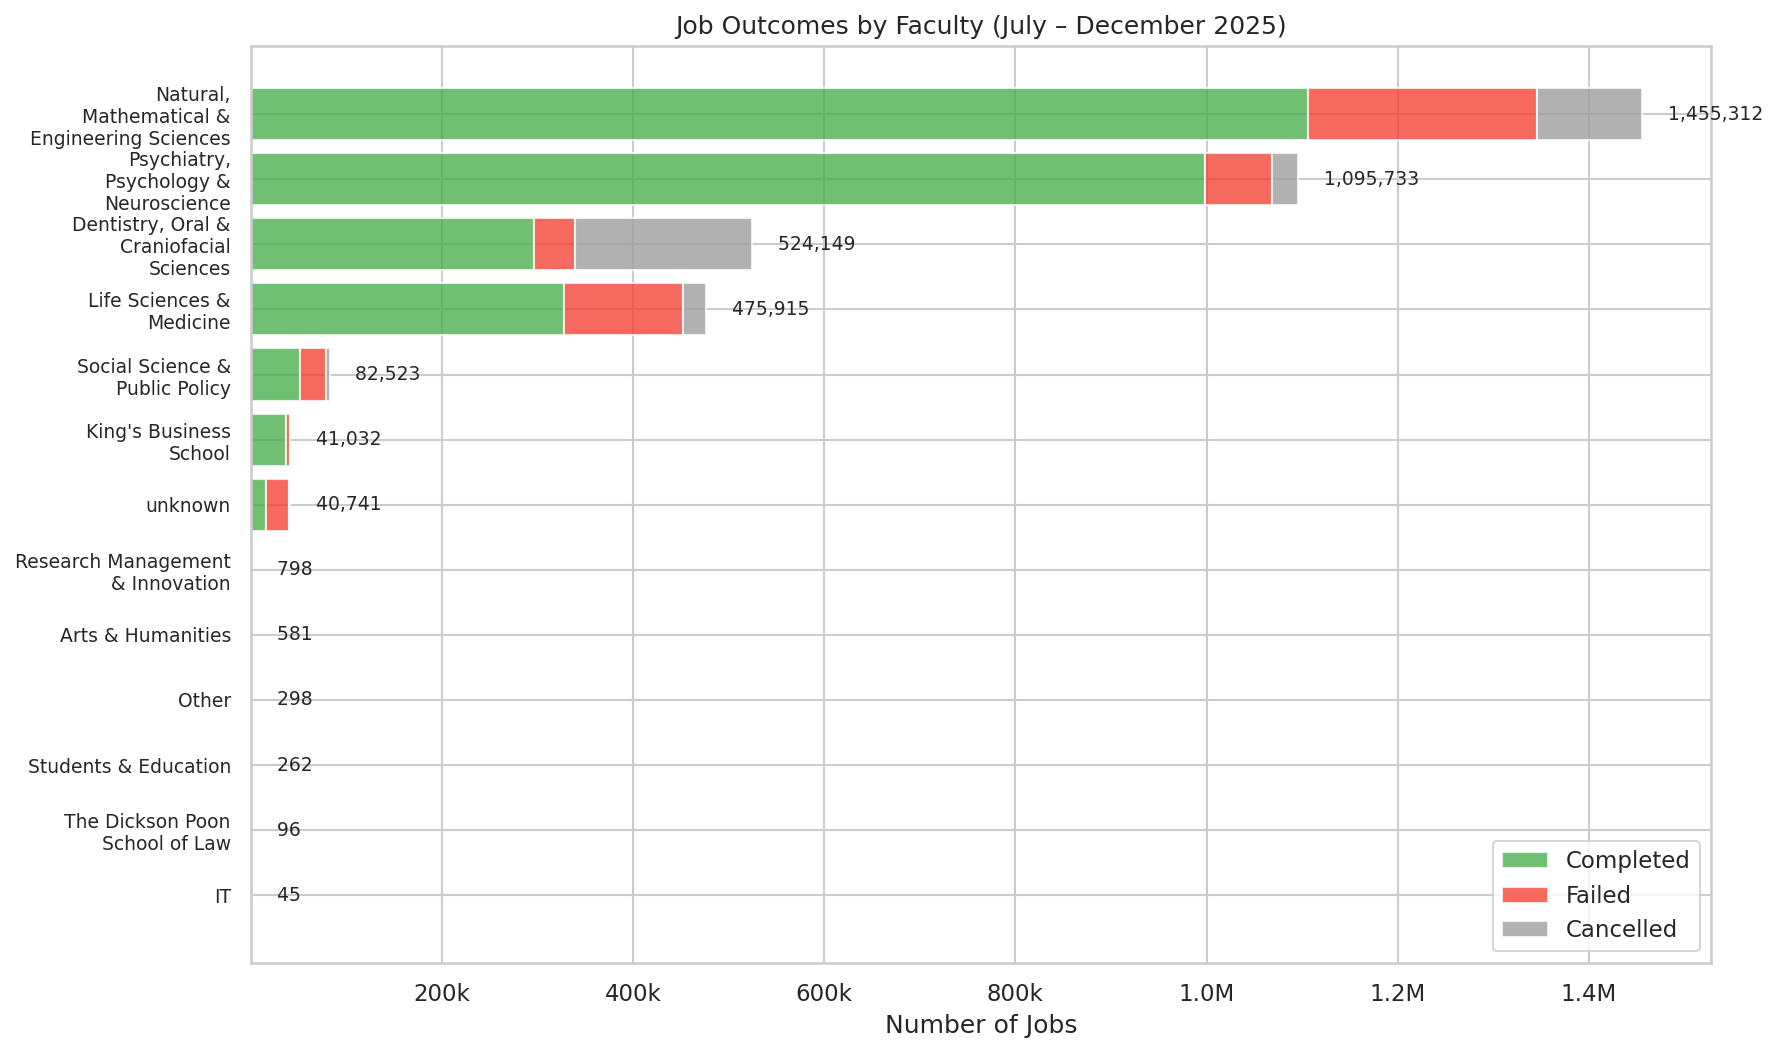


*Numbers at the tip of each bar show the total number of jobs submitted.*

**State definitions:**
- **Completed**: jobs that finished successfully (Slurm state COMPLETED).
- **Failed**: jobs that terminated abnormally — includes FAILED, TIMEOUT,
  NODE_FAIL, PREEMPTED, and OUT_OF_MEMORY.
- **Cancelled**: jobs cancelled by the user or an administrator before
  completion (excluded from failure counts as these are intentional).


In [19]:
df_out = df_agg.sort_values('job_count', ascending=True).copy()

fig, ax = plt.subplots(figsize=(12, max(7, len(df_out) * 0.55)))

y = range(len(df_out))
ax.barh(y, df_out['job_count_success'].values, color=C_OK,
        label='Completed', alpha=0.8)
ax.barh(y, df_out['job_count_failed'].values,
        left=df_out['job_count_success'].values,
        color=C_FAIL, label='Failed', alpha=0.8)
ax.barh(y, df_out['cancelled'].values,
        left=(df_out['job_count_success'] + df_out['job_count_failed']).values,
        color=C_CAN, label='Cancelled', alpha=0.8)

ax.set_yticks(list(y))
ax.set_yticklabels(df_out['faculty_short'].values, fontsize=9)
ax.set_xlabel('Number of Jobs')
ax.xaxis.set_major_formatter(COUNT_FMT)
ax.set_title(f'Job Outcomes by Faculty ({DATE_RANGE})')
ax.legend(loc='lower right')

# Annotate totals at tip
for i, (_, row) in enumerate(df_out.iterrows()):
    ax.text(row['job_count'] + df_out['job_count'].max() * 0.01, i,
            f'  {row["job_count"]:,}', va='center', fontsize=9)

plt.tight_layout()
savefig('faculty_job_outcomes.png')
plt.show()

display(Markdown('''
*Numbers at the tip of each bar show the total number of jobs submitted.*

**State definitions:**
- **Completed**: jobs that finished successfully (Slurm state COMPLETED).
- **Failed**: jobs that terminated abnormally — includes FAILED, TIMEOUT,
  NODE_FAIL, PREEMPTED, and OUT_OF_MEMORY.
- **Cancelled**: jobs cancelled by the user or an administrator before
  completion (excluded from failure counts as these are intentional).
'''))
